# MLPs for classification on Pearson's iris dataset

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Nov 26, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Nov 27, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Improvements to code and comments |

This notebook explores the application of Multilayer Perceptrons (MLPs) for classification tasks, focusing on the classic Iris dataset. The Iris dataset consists of measurements for three species of Iris flowers.

We will demonstrate how MLPs can be used to distinguish between these species based on their sepal and petal dimensions, providing a practical example of neural network classification.

## 1. Details on the dataset

The Iris dataset was used in Robert A. Fisher's classic paper:

 R. A. Fisher (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics. 7 (2). p. 179-–188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x

It consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

One flower species (Iris setosa) is linearly separable from the other two, but the other two are not linearly separable from each other.

![Iris flowers](https://miro.medium.com/v2/resize:fit:2550/0*GVjzZeYrir0R_6-X.png)

More information about this dataset is available at:

https://en.wikipedia.org/wiki/Iris_flower_data_set

| Variable Name | Role    | Type        | Units | Description                                                                 |
|---------------|---------|-------------|-------|-----------------------------------------------------------------------------|
| sepal length  | Feature | Continuous  | cm    |                                                                             |
| sepal width   | Feature | Continuous  | cm    |                                                                             |
| petal length  | Feature | Continuous  | cm    |                                                                             |
| petal width   | Feature | Continuous  | cm    |                                                                             |
| class         | Target  | Categorical |       | 0:Iris setosa, 1:Iris versicolor, 2:Iris virginica |


## 2. Setup

First, let's import the necessary libraries. We will use `torch` for building the neural network, `sklearn` for data handling, and `matplotlib` and `seaborn` for visualization.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Data analysis

In [2]:
# Load the dataset
iris = datasets.load_iris()
datasets.load_iris().keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
print(datasets.load_iris().DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
# Create a DataFrame from the iris dataset
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['class']   = iris.target
iris_df['species'] = iris.target_names[iris.target]

# Visualize it:
display(iris_df.sample(n=10).head(n=10))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class,species
73,6.1,2.8,4.7,1.2,1,versicolor
18,5.7,3.8,1.7,0.3,0,setosa
118,7.7,2.6,6.9,2.3,2,virginica
78,6.0,2.9,4.5,1.5,1,versicolor
76,6.8,2.8,4.8,1.4,1,versicolor
31,5.4,3.4,1.5,0.4,0,setosa
64,5.6,2.9,3.6,1.3,1,versicolor
141,6.9,3.1,5.1,2.3,2,virginica
68,6.2,2.2,4.5,1.5,1,versicolor
82,5.8,2.7,3.9,1.2,1,versicolor


<Figure size 1000x1000 with 0 Axes>

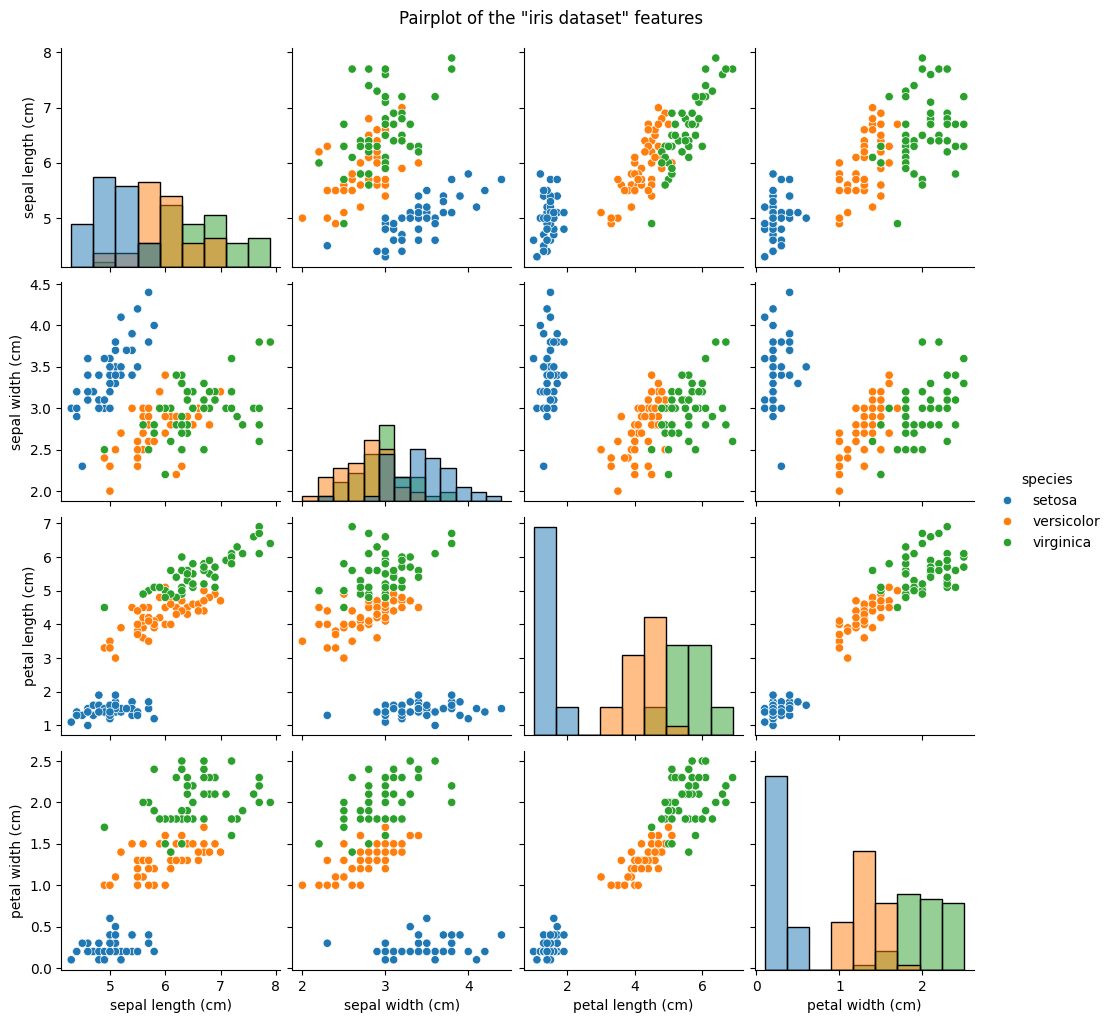

In [5]:
# Generate a pairplot of the dataset, colored by species
plt.figure(figsize=(10, 10))
sns.pairplot(iris_df, hue='species', diag_kind='hist', vars=iris.feature_names)
plt.suptitle('Pairplot of the "iris dataset" features', y=1.02)
plt.show()

## 4. Binary classification with a sigmoid output layer

## 4.1. Data preparation

The Iris dataset contains 4 features. To make visualization easy, we will select only **Sepal Length (index 0)** and **Petal Width (index 3)**.

We also need to preprocess the targets. The original dataset has 3 classes (0, 1, 2). Since we want to classify **Versicolor vs. Others**, we will create a binary label:

  * $y=1$ if the flower is Versicolor.
  * $y=0$ if the flower is Setosa or Virginica.

Finally, we must scale our inputs to the range $[-1, 1]$. This is essential for Neural Networks to ensure stable convergence and efficient gradient descent.

In [6]:
X_raw = iris.data
y_raw = iris.target

# Select Features: Sepal Length (col 0) and Petal Width (col 3)
X_selected = X_raw[:, [0, 3]]

# Create Binary Target: Versicolor (class 1) is our class 1, others are class 0
# Note: In original data, Versicolor is 1.
y_binary = np.where(y_raw == 1, 1, 0)

# Split into Train and Test sets (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_selected, y_binary, test_size=0.2, random_state=42
)

# Scale the data to range [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Convert to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)              # Ntrain x 2
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device) # Ntrain x 1
X_test_tensor  = torch.FloatTensor(X_test).to(device)               # Ntest  x 2
y_test_tensor  = torch.FloatTensor(y_test).unsqueeze(1).to(device)  # Ntest  x 1

print(f"Training feature shape: {X_train_tensor.shape}")
print(f"Testing class shape:    {y_test_tensor.shape}")

Training feature shape: torch.Size([120, 2])
Testing class shape:    torch.Size([30, 1])


### 4.2. Defining the Architecture

We will create a standard MLP.

  * **Input Layer:** 2 Neurons (Sepal Length, Petal Width).
  * **Hidden Layer:** 10 Neurons with ReLU activation.
  * **Output Layer:** 1 Neuron with Sigmoid activation (outputs "probability" between 0 and 1).

**Initialization:** We will explicitly initialize weights, in the hidden later, using the **Kaiming (He)** initialization, which is optimal for ReLU activations. This helps break symmetry and prevents vanishing gradients early in training. Biases are included by default in `nn.Linear`. In the output layer, we will use **Xavier (Glorot)** initialization, which works well with sigmoid functions.

In [7]:
class IrisMLP(nn.Module):
    def __init__(self):
        super(IrisMLP, self).__init__()
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.fc1 = nn.Linear(2, 10, bias=True)   # Layer 1: 2 inputs -> 10 hidden neurons
        self.fc2 = nn.Linear(10, 1, bias=True)   # Layer 2: 10 hidden -> 1 output neuron

        # Apply Weight Initialization
        self._init_weights()

    def _init_weights(self):
        # Kaiming He initialization for layers with ReLU
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
        nn.init.constant_(self.fc1.bias, 0)

        # Xavier Glorot for the output layer (Sigmoid)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, 0)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

model = IrisMLP().to(device)
print(model)

IrisMLP(
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)


### 4.3. Training the Model

We will use **Binary Cross Entropy Loss** (`BCELoss`) and the **SGD** optimizer.

We will also track the **Norm of the Gradients**. This is a useful metric for debugging; if the norm explodes, our learning rate is too high. If it hits zero, the network has stopped learning.

#### Binary Cross-Entropy Loss (BCE Loss)

Binary Cross-Entropy Loss is a fundamental loss function used in binary classification tasks. It measures the performance of a classification model whose output is a probability value between 0 and 1. BCE loss increases as the predicted probability diverges from the actual label.

**Purpose:**

1.  **Quantifying Error:** It quantifies the difference between the true labels and the predicted probabilities.
2.  **Driving Learning:** It provides a clear gradient signal to the neural network during training, guiding the model to adjust its weights and biases to reduce this difference.
3.  **Suitable for Probabilities:** It is particularly well-suited for models that output probabilities (e.g., using a sigmoid activation function in the output layer), as it penalizes predictions that are confident and wrong more heavily than predictions that are less confident.

**Mathematical Formulation:**

Given a true binary label $y \in \{0, 1\}$ and a predicted probability $\hat{y} \in [0, 1]$, the Binary Cross-Entropy loss for a single sample is calculated as:

$$ \text{BCE}(y, \hat{y}) = -(y \ln(\hat{y}) + (1 - y) \ln(1 - \hat{y})) $$

Where:
*   $y$: The true label (0 or 1).
*   $\hat{y}$: The predicted probability of the positive class (i.e., $P(y=1)$).

The total BCE loss for a batch of $N$ samples is typically the average of the individual BCE losses:

$$ \text{Total BCE} = \frac{1}{N} \sum_{i=1}^{N} \text{BCE}(y_i, \hat{y}_i) $$

In [8]:
# Hyperparameters
learning_rate = 0.1
epochs = 2000

loss_fn   = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_history = []

print("Starting Training...")
print("-" * 35)
print(f"{'Epoch':^6} | {'Loss':^10} | {'Grad Norm':^10}")
print("-" * 35)

for epoch in range(1, epochs+1):
    # 1. Forward pass
    outputs = model(X_train_tensor)
    loss = loss_fn(outputs, y_train_tensor)

    # 2. Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Calculate Gradient Norm (L2 norm of all gradients vectors)
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item()**2
    total_norm = total_norm ** 0.5

    # 3. Update weights
    optimizer.step()

    # Logging
    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"{epoch:>6} | {loss.item():10.6f} | {total_norm:10.6f}")

Starting Training...
-----------------------------------
Epoch  |    Loss    | Grad Norm 
-----------------------------------
   100 |   0.366690 |   0.108357
   200 |   0.285426 |   0.077232
   300 |   0.237406 |   0.061390
   400 |   0.207107 |   0.049396
   500 |   0.187101 |   0.040357
   600 |   0.173535 |   0.033677
   700 |   0.163888 |   0.029075
   800 |   0.156571 |   0.025108
   900 |   0.151223 |   0.021418
  1000 |   0.147180 |   0.019088
  1100 |   0.144001 |   0.017081
  1200 |   0.141546 |   0.015103
  1300 |   0.139595 |   0.013646
  1400 |   0.137984 |   0.012483
  1500 |   0.136637 |   0.011474
  1600 |   0.135500 |   0.010535
  1700 |   0.134474 |   0.009886
  1800 |   0.133594 |   0.009224
  1900 |   0.132822 |   0.008762
  2000 |   0.132125 |   0.007932


### 4.4. Analysis: Learning Curves

Let's view the loss reduction over time. We plot this on a **logarithmic scale** to better see the behavior as the loss approaches zero.

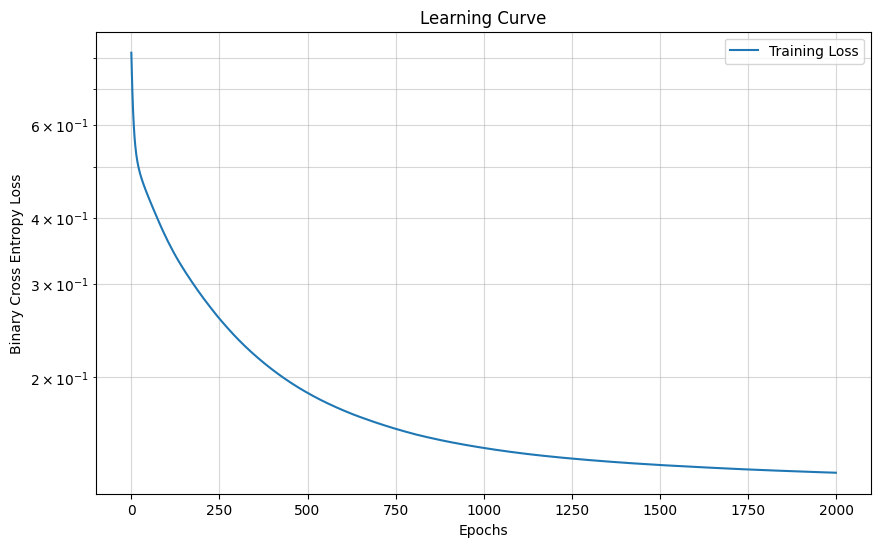

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Training Loss')
plt.yscale('log')
plt.title('Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy Loss')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

### 4.5. Evaluation: Test Error

Now we estimate the model's performance on unseen data. We apply a threshold of $0.5$ to the probability output to classify samples.

In [10]:
model.eval() # Set model to evaluation mode

with torch.no_grad():
    y_pred_prob = model(X_test_tensor)
    y_pred_class = (y_pred_prob >= 0.5).float()

    accuracy = torch.mean((y_pred_class == y_test_tensor).float()).item()
    test_error = 1.0 - accuracy

print(f"Test Accuracy: {100*accuracy  :6.2f}%")
print(f"Test Error:    {100*test_error:6.2f}%")

Test Accuracy: 100.00%
Test Error:      0.00%


### 4.6. Visualization: Decision Surface

This is the most important part to understand *what* the network actually learned. We will generate a meshgrid covering the $[-1, 1]$ input space and color it based on the model's prediction.

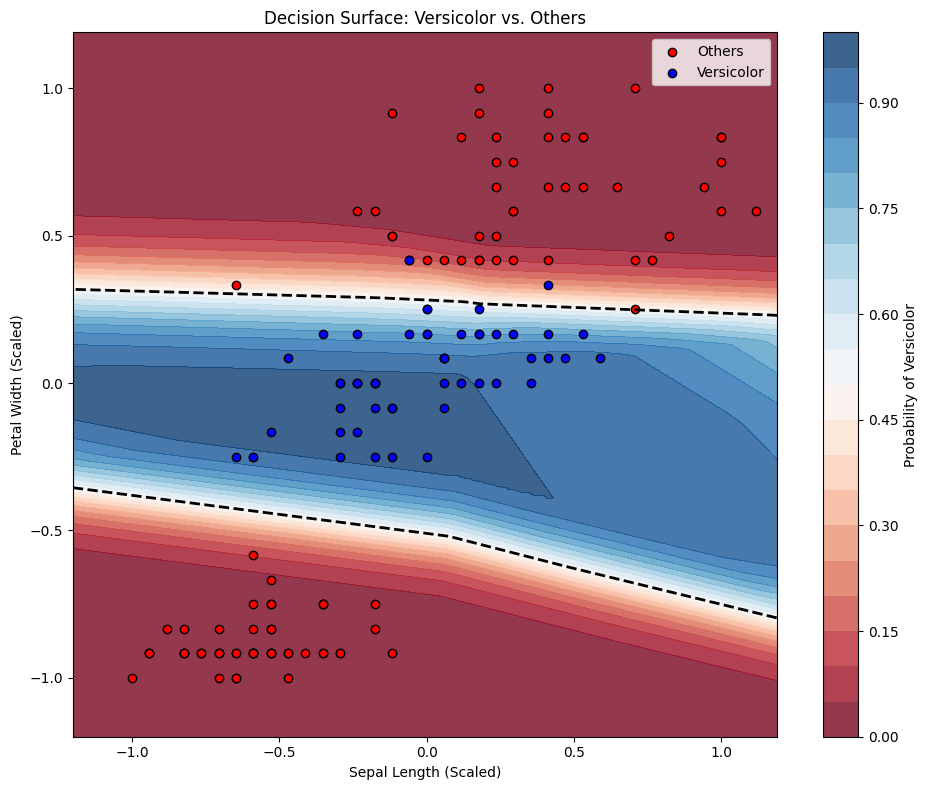

In [11]:
def plot_decision_boundary(model, X, y):
    # Define bounds of the domain
    x_min, x_max = -1.2, 1.2
    y_min, y_max = -1.2, 1.2
    h = 0.01  # Step size in the mesh

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Flatten meshgrid and pass through model
    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)

    with torch.no_grad():
        Z = model(grid_tensor).numpy()

    Z = Z.reshape(xx.shape)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Contour plot for probability zones
    contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.8)
    fig.colorbar(contour, ax=ax, label='Probability of Versicolor')

    # Add the 0.5 decision boundary contour
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)

    # Scatter plot of data points
    # Class 0 (Others: Setosa, Virginica)
    ax.scatter(X[y==0, 0], X[y==0, 1], c='red',  label='Others',     edgecolors='k')
    # Class 1 (Versicolor)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Versicolor', edgecolors='k')

    ax.set_title('Decision Surface: Versicolor vs. Others')
    ax.set_xlabel('Sepal Length (Scaled)')
    ax.set_ylabel('Petal Width (Scaled)')
    ax.legend()
    ax.set_aspect('equal', 'box')
    fig.tight_layout()
    plt.show()

plot_decision_boundary(model, scaler.transform(X_selected), y_binary)

## 5. Extending to Multiclass Classification with Softmax
Now, let's adapt our model and data for multiclass classification. Instead of just distinguishing Versicolor from others, we will now train the model to classify all three species: Setosa (0), Versicolor (1), and Virginica (2).

### 5.1. Data Preparation for Multiclass
We will reuse the `X_selected` features (Sepal Length and Petal Width). For the target, we will now use the original `y_raw` labels (0, 1, 2) directly, as PyTorch's `CrossEntropyLoss` expects class indices as targets, not one-hot encodings.

In [12]:
# Load the dataset (already loaded in previous steps, but re-assigning for clarity)
iris = datasets.load_iris()
X_raw = iris.data
y_raw = iris.target

# Select Features: Sepal Length (col 0) and Petal Width (col 3)
X_selected = X_raw[:, [0, 3]]

# For multiclass, we use the original y_raw (0, 1, 2)
# Split into Train and Test sets (80% train, 20% test)

# The stratify option in scikit-learn's train_test_split function is used to
# ensure that the training and testing sets maintain the same proportion of
# samples for each class as in the original dataset. This is particularly
# in classification problems, especially when dealing with imbalanced datasets.
X_train_raw_multi, X_test_raw_multi, y_train_multi, y_test_multi = train_test_split(
    X_selected, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# Scale the data to range [-1, 1] using the previously fitted scaler
# We'll use the same scaler as before to ensure consistency if it was trained
# on the same feature set.
# If a new scaling is desired, a new scaler should be initialized and fitted.
# For this demonstration, we'll re-fit to the full X_selected to ensure a fresh scale.
scaler_multi  = MinMaxScaler(feature_range=(-1, 1))
X_train_multi = scaler_multi.fit_transform(X_train_raw_multi)
X_test_multi  = scaler_multi.transform(X_test_raw_multi)

# Convert to PyTorch Tensors
X_train_tensor_multi = torch.FloatTensor(X_train_multi).to(device)
y_train_tensor_multi = torch.LongTensor (y_train_multi).to(device) # CrossEntropyLoss expects LongTensor
X_test_tensor_multi  = torch.FloatTensor( X_test_multi).to(device)
y_test_tensor_multi  = torch.LongTensor ( y_test_multi).to(device) # CrossEntropyLoss expects LongTensor

print(f"Training Input Shape: { X_train_tensor_multi.shape}")
print(f"Training Target Shape: {y_train_tensor_multi.shape}")

Training Input Shape: torch.Size([120, 2])
Training Target Shape: torch.Size([120])


### 5.2. Defining the Multiclass Architecture

For multiclass classification, our output layer will now have 3 neurons, one for each class. We will use `nn.Linear` with 3 outputs. PyTorch's [`nn.CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) internally applies [`LogSoftmax`](https://docs.pytorch.org/docs/stable/generated/torch.nn.LogSoftmax.html) and then [`NLLLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html), so we typically **do not** apply `Softmax` explicitly as the final activation layer in the model when using `CrossEntropyLoss` directly. The output will be raw logits.

In [13]:
class IrisMLPMulti(nn.Module):
    def __init__(self):
        super(IrisMLPMulti, self).__init__()
        # Layer 1: 2 inputs -> 10 hidden neurons
        self.fc1 = nn.Linear(2, 10, bias=True)
        self.relu = nn.ReLU()
        # Layer 2: 10 hidden -> 3 output neurons (for 3 classes)
        self.fc2 = nn.Linear(10, 3, bias=True) # Output for 3 classes

        # Note: We do NOT apply Softmax here, as nn.CrossEntropyLoss expects raw logits.

        # Apply Weight Initialization
        self._init_weights()

    def _init_weights(self):
        # Kaiming He initialization for layers with ReLU
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
        nn.init.constant_(self.fc1.bias, 0)

        # For the final layer before CrossEntropyLoss, use Xavier Uniform (Glorot)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, 0)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out) # Raw logits output
        return out

model_multi = IrisMLPMulti().to(device)
print(model_multi)

IrisMLPMulti(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=3, bias=True)
)


### 5.3. Training the Multiclass Model

For multiclass classification, we will use **Cross Entropy Loss** (`nn.CrossEntropyLoss`) and the **Adam** optimizer. `CrossEntropyLoss` expects raw logits from the model and integer class labels as targets.



In [14]:
# Hyperparameters
learning_rate_multi = 0.01
epochs_multi = 2000

loss_fn_multi = nn.CrossEntropyLoss() # Suitable for multiclass classification with raw logits
optimizer_multi = optim.Adam(model_multi.parameters(), lr=learning_rate_multi)

loss_history_multi = []

print("Starting Multiclass Training...")
print("-" * 35)
print(f"{'Epoch':^6} | {'Loss':^10} | {'Grad Norm':^10}")
print("-" * 35)

for epoch in range(1, epochs_multi+1):
    # 1. Forward pass
    outputs_multi = model_multi(X_train_tensor_multi)
    loss_multi    = loss_fn_multi(outputs_multi, y_train_tensor_multi)

    # 2. Backward pass
    optimizer_multi.zero_grad()
    loss_multi.backward()

    # Calculate Gradient Norm
    total_norm_multi = 0
    for p in model_multi.parameters():
        if p.grad is not None:
            param_norm_multi = p.grad.data.norm(2)
            total_norm_multi += param_norm_multi.item() ** 2
    total_norm_multi = total_norm_multi ** 0.5

    # 3. Update weights
    optimizer_multi.step()

    # Logging
    loss_history_multi.append(loss_multi.item())

    if epoch % 100 == 0:
        print(f"{epoch:>6} | {loss_multi.item():10.6f} | {total_norm_multi:10.6f}")

Starting Multiclass Training...
-----------------------------------
Epoch  |    Loss    | Grad Norm 
-----------------------------------
   100 |   0.191078 |   0.095361
   200 |   0.098990 |   0.015832
   300 |   0.092739 |   0.005952
   400 |   0.091239 |   0.003305
   500 |   0.090573 |   0.002330
   600 |   0.090180 |   0.001625
   700 |   0.089945 |   0.001261
   800 |   0.089783 |   0.001003
   900 |   0.089669 |   0.000833
  1000 |   0.089585 |   0.000706
  1100 |   0.089520 |   0.000618
  1200 |   0.089470 |   0.001138
  1300 |   0.089431 |   0.000454
  1400 |   0.089399 |   0.000419
  1500 |   0.089370 |   0.000390
  1600 |   0.089346 |   0.000372
  1700 |   0.089324 |   0.000359
  1800 |   0.089304 |   0.000353
  1900 |   0.089284 |   0.000352
  2000 |   0.089266 |   0.000362


### 5.4. Analysis: Multiclass Learning Curve
Let's view the loss reduction over time for our multiclass model. We'll plot this on a **logarithmic scale** to observe the training dynamics as the loss approaches zero.

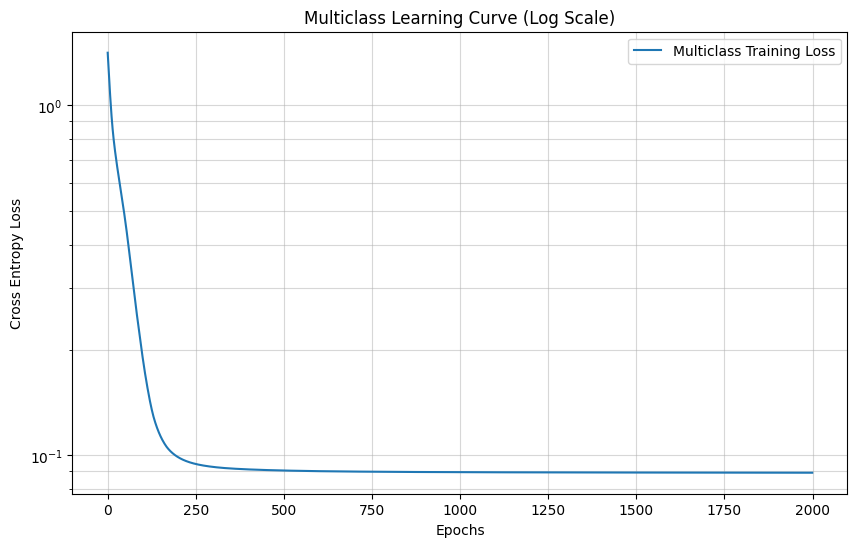

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history_multi, label='Multiclass Training Loss')
plt.yscale('log')
plt.title('Multiclass Learning Curve (Log Scale)')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

### 5.5. Evaluation: Multiclass Test Accuracy
We'll now estimate the multiclass model's performance on unseen test data. For multiclass, we select the class with the highest logit as the model's prediction.

In [16]:
model_multi.eval() # Set model to evaluation mode
with torch.no_grad():
    # Get raw logits from the model
    outputs_multi_test = model_multi(X_test_tensor_multi)

    # Get predicted class by taking the argmax over the output logits
    _, predicted_classes_multi = torch.max(outputs_multi_test, 1)

    # Calculate accuracy
    accuracy_multi = torch.mean((y_pred_class == y_test_tensor).float()).item()

print(f"Multiclass Test Accuracy: {accuracy_multi * 100:.2f}%")

Multiclass Test Accuracy: 100.00%


### 5.6. Visualization: Multiclass Decision Surface
Similar to the binary classification, we will generate a meshgrid over the input space and use the multiclass model to predict the class for each point. We'll then color the regions according to the predicted class.

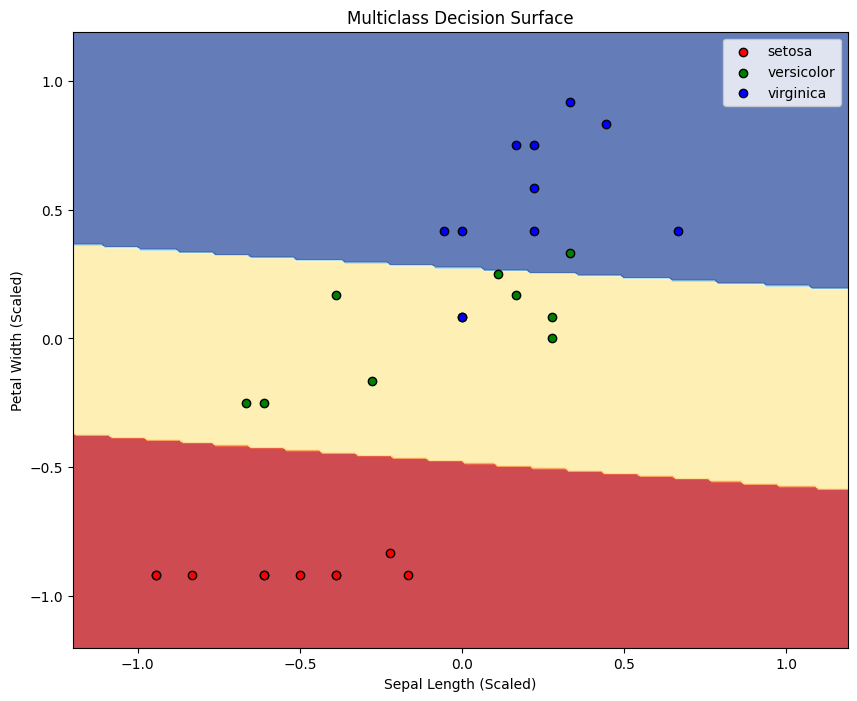

In [17]:
def plot_multiclass_decision_boundary(model, X, y, class_names):
    # Define bounds of the domain [-1, 1] as per our scaling
    x_min, x_max = -1.2, 1.2
    y_min, y_max = -1.2, 1.2
    h = 0.01  # Step size in the mesh

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Flatten meshgrid and pass through model
    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)

    with torch.no_grad():
        outputs = model(grid_tensor) # Get raw logits
        _, Z = torch.max(outputs, 1) # Get predicted class
        Z = Z.cpu().numpy()

    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(10, 8))

    # Contour plot for decision regions
    # Using plt.contourf with levels to define boundaries for each class
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)

    # Define colors for scatter plot (adjust if you have more classes)
    colors = ['red', 'green', 'blue']

    # Scatter plot of data points
    for i, class_name in enumerate(class_names):
        plt.scatter(X[y==i, 0], X[y==i, 1], c=colors[i], label=class_name, edgecolors='k')

    plt.title('Multiclass Decision Surface')
    plt.xlabel('Sepal Length (Scaled)')
    plt.ylabel('Petal Width (Scaled)')
    plt.legend()
    plt.show()

# Get original class names for labeling
iris_class_names = iris.target_names

# Convert tensor data back to numpy for plotting
plot_multiclass_decision_boundary(model_multi, X_test_tensor_multi.numpy(), y_test_multi.flatten(), iris_class_names)


### 5.7. Confusion Matrix for Multiclass Classification
A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. It helps to understand which classes are being confused with each other.

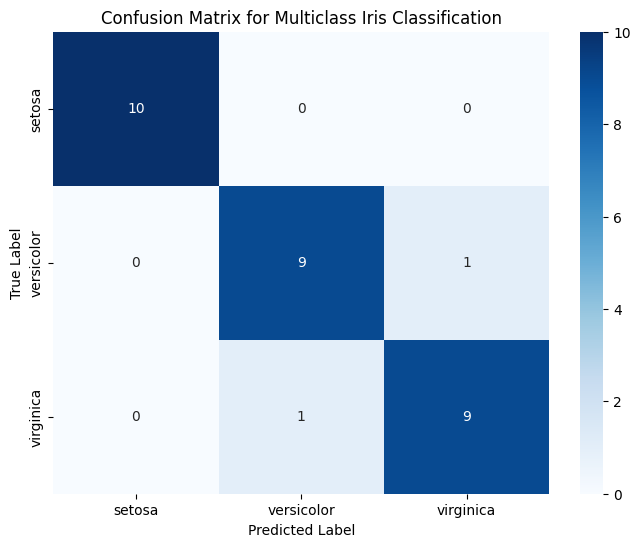

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_multi.eval() # Set model to evaluation mode
with torch.no_grad():
    outputs_multi_test = model_multi(X_test_tensor_multi)
    _, predicted_classes_multi = torch.max(outputs_multi_test, 1)

# Convert tensors to numpy for sklearn's confusion_matrix
y_true = y_test_tensor_multi.numpy()
y_pred = predicted_classes_multi.numpy()

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Get class names for labels
class_names = iris.target_names

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Multiclass Iris Classification')
plt.show()